<a href="https://colab.research.google.com/github/dibyajyoti-15/Autonomous-Data-Pipeline-Analytics-Agent/blob/main/2401030009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install -q langchain langchain-community pandas matplotlib sqlalchemy

In [11]:
import sqlite3
import os

# Remove existing database file if it exists, to ensure a clean start
if os.path.exists("analytics.db"):
    os.remove("analytics.db")

# Create database
conn = sqlite3.connect("analytics.db")
cursor = conn.cursor()

# Drop old tables if rerun
cursor.execute("DROP TABLE IF EXISTS customers")
cursor.execute("DROP TABLE IF EXISTS products")
cursor.execute("DROP TABLE IF EXISTS sales")

# Create customers table
cursor.execute("""
CREATE TABLE customers (
    customer_id INTEGER,
    customer_name TEXT,
    region TEXT
)
""")

# Create products table
cursor.execute("""
CREATE TABLE products (
    product_id INTEGER,
    product_name TEXT,
    category TEXT
)
""")

# Create sales table
cursor.execute("""
CREATE TABLE sales (
    sale_id INTEGER,
    customer_id INTEGER,
    product_id INTEGER,
    amount REAL,
    sale_date TEXT
)
""")

conn.commit()

print(" Database created successfully")

 Database created successfully


In [13]:
cursor.executemany(
    "INSERT INTO customers VALUES (?, ?, ?)",
    [
        (1, 'Rahul', 'East'),
        (2, 'Priya', 'West'),
        (3, 'Amit', 'North'),
        (4, 'Sneha', 'South')
    ]
)

cursor.executemany(
    "INSERT INTO products VALUES (?, ?, ?)",
    [
        (101, 'Laptop', 'Electronics'),
        (102, 'Phone', 'Electronics'),
        (103, 'Chair', 'Furniture'),
        (104, 'Table', 'Furniture')
    ]
)

cursor.executemany(
    "INSERT INTO sales VALUES (?, ?, ?, ?, ?)",
    [
        (1001, 1, 101, 50000, '2025-01-10'),
        (1002, 2, 102, 30000, '2025-02-12'),
        (1003, 3, 103, 7000, '2025-03-15'),
        (1004, 4, 104, 12000, '2025-04-20')
    ]
)

conn.commit()

print(" Dummy data inserted")

 Dummy data inserted


In [14]:
cursor.executemany(
    "INSERT INTO customers VALUES (?, ?, ?)",
    [
        (1, 'Rahul', 'East'),
        (2, 'Priya', 'West'),
        (3, 'Amit', 'North'),
        (4, 'Sneha', 'South')
    ]
)

cursor.executemany(
    "INSERT INTO products VALUES (?, ?, ?)",
    [
        (101, 'Laptop', 'Electronics'),
        (102, 'Phone', 'Electronics'),
        (103, 'Chair', 'Furniture'),
        (104, 'Table', 'Furniture')
    ]
)

cursor.executemany(
    "INSERT INTO sales VALUES (?, ?, ?, ?, ?)",
    [
        (1001, 1, 101, 50000, '2025-01-10'),
        (1002, 2, 102, 30000, '2025-02-12'),
        (1003, 3, 103, 7000, '2025-03-15'),
        (1004, 4, 104, 12000, '2025-04-20')
    ]
)

conn.commit()

print(" Dummy data inserted")

 Dummy data inserted


In [15]:
import pandas as pd

print("Customers Table")
print(pd.read_sql("SELECT * FROM customers", conn))

print("\nProducts Table")
print(pd.read_sql("SELECT * FROM products", conn))

print("\nSales Table")
print(pd.read_sql("SELECT * FROM sales", conn))

Customers Table
    customer_id customer_name region
0             1         Rahul   East
1             2         Priya   West
2             3          Amit  North
3             4         Sneha  South
4             1         Rahul   East
5             2         Priya   West
6             3          Amit  North
7             4         Sneha  South
8             1         Rahul   East
9             2         Priya   West
10            3          Amit  North
11            4         Sneha  South

Products Table
    product_id product_name     category
0          101       Laptop  Electronics
1          102        Phone  Electronics
2          103        Chair    Furniture
3          104        Table    Furniture
4          101       Laptop  Electronics
5          102        Phone  Electronics
6          103        Chair    Furniture
7          104        Table    Furniture
8          101       Laptop  Electronics
9          102        Phone  Electronics
10         103        Chair    Furni

In [17]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///analytics.db")

print("Available Tables:")
print(db.get_usable_table_names())

print("\nSchema Info:")
print(db.table_info)

Available Tables:
['customers', 'products', 'sales']

Schema Info:

CREATE TABLE customers (
	customer_id INTEGER, 
	customer_name TEXT, 
	region TEXT
)

/*
3 rows from customers table:
customer_id	customer_name	region
1	Rahul	East
2	Priya	West
3	Amit	North
*/


CREATE TABLE products (
	product_id INTEGER, 
	product_name TEXT, 
	category TEXT
)

/*
3 rows from products table:
product_id	product_name	category
101	Laptop	Electronics
102	Phone	Electronics
103	Chair	Furniture
*/


CREATE TABLE sales (
	sale_id INTEGER, 
	customer_id INTEGER, 
	product_id INTEGER, 
	amount REAL, 
	sale_date TEXT
)

/*
3 rows from sales table:
sale_id	customer_id	product_id	amount	sale_date
1001	1	101	50000.0	2025-01-10
1002	2	102	30000.0	2025-02-12
1003	3	103	7000.0	2025-03-15
*/


In [18]:
query = """
SELECT customers.region, SUM(sales.amount) AS total_sales
FROM sales
JOIN customers ON sales.customer_id = customers.customer_id
GROUP BY customers.region
"""

df = pd.read_sql(query, conn)

print(df)

  region  total_sales
0   East     450000.0
1  North      63000.0
2  South     108000.0
3   West     270000.0


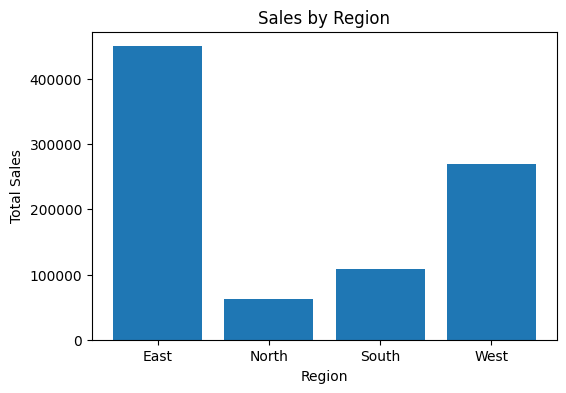

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(df["region"], df["total_sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [20]:
for _, row in df.iterrows():
    print(f"Region {row['region']} generated total sales of {row['total_sales']}")

Region East generated total sales of 450000.0
Region North generated total sales of 63000.0
Region South generated total sales of 108000.0
Region West generated total sales of 270000.0
